In [2]:
import scanpy as sc

import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
adata = sc.read_h5ad('../../h5ad/parse_snRNA-seq_raw.h5ad')
#adata_filter = adata

In [3]:
tenx_meta = pd.read_csv('../../../10x_HPAP/metadata10x.csv', index_col=0)

/tmp/ipykernel_2642/3245602902.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  tenx_meta = pd.read_csv('../../../10x_HPAP/metadata10x.csv', index_col=0)


In [ ]:
tenx_meta.columns

Index(['sample', 'DonorID', 'Diagnosis', 'Age (Y)', 'BMI', 'HBA1C', 'AAB(+/-)',
       'Duration', 'Age of onset', 'group', 'n_genes', 'doublet_score',
       'predicted_doublet', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'annotation',
       '_indices', '_scvi_batch', '_scvi_labels'],
      dtype='object')

In [ ]:
parse_meta = adata.obs[['total_counts', 'gene_count']]

In [ ]:
tenx_meta[['gene_count']] = tenx_meta[['n_genes_by_counts']]

In [ ]:
tenx_meta = tenx_meta[['total_counts', 'gene_count']] 

In [ ]:
tenx_meta['exp'] = '10x'

/tmp/ipykernel_145878/1115958276.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tenx_meta['exp'] = '10x'


In [ ]:
parse_meta['exp'] = 'Parse'

/tmp/ipykernel_145878/3025049650.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  parse_meta['exp'] = 'Parse'


In [ ]:
merged_meta = pd.concat([tenx_meta, parse_meta])

In [ ]:
groups = merged_meta.groupby('exp')

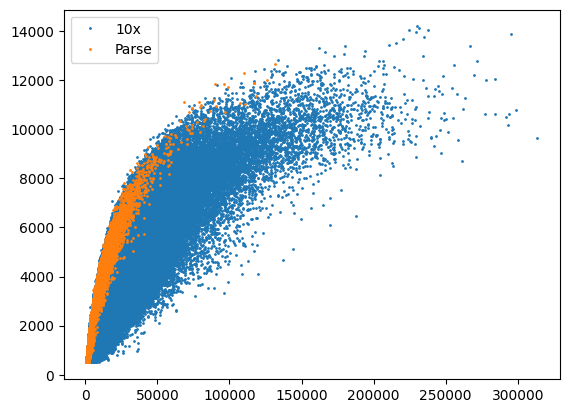

In [ ]:
fig, ax = plt.subplots()
ax.margins(0.05) # Optional, just adds 5% padding to the autoscaling
for name, group in groups:
    ax.plot(group.total_counts, group.gene_count, marker='o', linestyle='', ms=1, label=name, )
ax.legend()
